# Composable Exit Rules and Portfolio Limits
**Docker image**: `ml4t`

**Chapter 19: Risk Management**

## Purpose
Use the `ml4t.backtest.risk` library to evaluate position-level exit rules,
compose rule priorities, and evaluate portfolio-level risk limits.

## Learning Objectives
After completing this notebook, you will be able to:
- Configure position-level exit rules (`StopLoss`, `TrailingStop`, `TakeProfit`)
- Compose multiple rules with priority and boolean logic (`RuleChain`, `AllOf`, `AnyOf`)
- Set up portfolio-wide risk limits (`MaxDrawdownLimit`, `DailyLossLimit`)
- Interpret each rule's action, fill price, and reason

## Book reference
Sections 19.4 (drawdowns and recovery), 19.7 (adaptive controls), and 19.8
(kill switches and governance).

## Prerequisites
- Comfort with the backtest framework introduced in Chapter 16
- `02_exit_strategies` and `03_position_sizing_mae_mfe` for the rules'
  analytical motivation

In [1]:
"""Configure and evaluate position rules and portfolio limits."""

import numpy as np
import plotly.graph_objects as go
import polars as pl
from ml4t.backtest.risk import (
    AllOf,
    AnyOf,
    DailyLossLimit,
    GrossExposureLimit,
    MaxDrawdownLimit,
    MaxPositionsLimit,
    NetExposureLimit,
    PortfolioState,
    PositionState,
    RuleChain,
    ScaledExit,
    StopLoss,
    TakeProfit,
    TighteningTrailingStop,
    TimeExit,
    TrailingStop,
)

from data import load_etfs
from utils.style import COLORS, ml4t_palette, show_plotly_with_alt

In [2]:
N_BARS = 252

## 1. Position-Level Exit Rules

The `ml4t.backtest.risk.position` module provides exit rules that operate on
individual positions. Each rule evaluates a `PositionState` and returns a
`PositionAction` (HOLD, EXIT_FULL, EXIT_PARTIAL, or ADJUST_STOP).

### Creating Position States

A compact state factory keeps the examples focused on rule behavior. Long and
short returns use the entry notional as the common denominator.

In [3]:
def create_position_state(
    symbol: str = "SPY",
    side: str = "long",
    entry_price: float = 100.0,
    current_price: float = 100.0,
    bars_held: int = 0,
    bar_open: float | None = None,
    bar_high: float | None = None,
    bar_low: float | None = None,
    high_water_mark: float | None = None,
    low_water_mark: float | None = None,
) -> PositionState:
    """Create a PositionState for rule evaluation."""
    if side not in {"long", "short"}:
        raise ValueError("side must be 'long' or 'short'")

    direction = 1.0 if side == "long" else -1.0
    unrealized_return = direction * (current_price - entry_price) / entry_price
    high_mark = max(entry_price, current_price) if high_water_mark is None else high_water_mark
    low_mark = min(entry_price, current_price) if low_water_mark is None else low_water_mark

    return PositionState(
        asset=symbol,
        side=side,
        entry_price=entry_price,
        current_price=current_price,
        bar_open=current_price if bar_open is None else bar_open,
        bar_high=current_price if bar_high is None else bar_high,
        bar_low=current_price if bar_low is None else bar_low,
        quantity=100.0,
        initial_quantity=100.0,
        unrealized_pnl=direction * (current_price - entry_price) * 100.0,
        unrealized_return=unrealized_return,
        bars_held=bars_held,
        high_water_mark=high_mark,
        low_water_mark=low_mark,
        max_favorable_excursion=max(0, unrealized_return),
        max_adverse_excursion=min(0, unrealized_return),
    )

### Static Exit Rules

Static rules have fixed thresholds that don't change during the position lifetime.

In [4]:
stop_loss = StopLoss(pct=0.05)
take_profit = TakeProfit(pct=0.10)
time_exit = TimeExit(max_bars=20)

**`StopLoss`** exits once the loss from the entry price reaches the percentage it was
configured with. It measures against the entry, so the exit level never moves as the
position gains.

In [5]:
scenarios = [
    ("Entry price", 100.0, 100.0),
    ("Down 3%", 100.0, 97.0),
    ("Down 5% (trigger)", 100.0, 95.0),
    ("Down 7%", 100.0, 93.0),
]

for name, entry, current in scenarios:
    state = create_position_state(entry_price=entry, current_price=current)
    action = stop_loss.evaluate(state)
    status = "TRIGGERED" if action.action.name != "HOLD" else "hold"
    print(f"  {name}: entry=${entry}, current=${current} -> {status}")
    if action.reason:
        print(f"    Reason: {action.reason}")

  Entry price: entry=$100.0, current=$100.0 -> hold
  Down 3%: entry=$100.0, current=$97.0 -> hold
  Down 5% (trigger): entry=$100.0, current=$95.0 -> TRIGGERED
    Reason: stop_loss_5.0%
  Down 7%: entry=$100.0, current=$93.0 -> TRIGGERED
    Reason: stop_loss_5.0%


**`TakeProfit`** is the mirror image: it exits once the gain from entry reaches its target.

In [6]:
scenarios = [
    ("Entry price", 100.0, 100.0),
    ("Up 5%", 100.0, 105.0),
    ("Above 10% (trigger)", 100.0, 110.01),
    ("Up 15%", 100.0, 115.0),
]

for name, entry, current in scenarios:
    state = create_position_state(entry_price=entry, current_price=current)
    action = take_profit.evaluate(state)
    status = "TRIGGERED" if action.action.name != "HOLD" else "hold"
    print(f"  {name}: entry=${entry}, current=${current} -> {status}")

  Entry price: entry=$100.0, current=$100.0 -> hold
  Up 5%: entry=$100.0, current=$105.0 -> hold
  Above 10% (trigger): entry=$100.0, current=$110.01 -> TRIGGERED
  Up 15%: entry=$100.0, current=$115.0 -> TRIGGERED


**`TimeExit(max_bars=20)`** exits after 20 bars regardless of P&L.

In [7]:
for bars in [5, 15, 19, 20, 25]:
    state = create_position_state(bars_held=bars)
    action = time_exit.evaluate(state)
    status = "TRIGGERED" if action.action.name != "HOLD" else "hold"
    print(f"  Bars held: {bars} -> {status}")

  Bars held: 5 -> hold
  Bars held: 15 -> hold
  Bars held: 19 -> hold
  Bars held: 20 -> TRIGGERED
  Bars held: 25 -> TRIGGERED


### Dynamic Exit Rules

Dynamic rules have thresholds that adapt to position performance.

**`TrailingStop`** measures from the highest price reached since entry rather than from the
entry itself, so the exit level ratchets up with the position and never back down.
The rule uses the high-water mark through the prior completed bar, then updates
that state after the current bar is evaluated.

In [8]:
trailing_stop = TrailingStop(pct=0.05)

states = [
    create_position_state(entry_price=100, current_price=100),
    create_position_state(entry_price=100, current_price=110),
    create_position_state(entry_price=100, current_price=120),  # New high
    create_position_state(entry_price=100, current_price=116),  # Down 3.3%
    create_position_state(entry_price=100, current_price=114),  # Down 5% (trigger)
]

hwm = 100.0
for state in states:
    state.high_water_mark = hwm
    action = trailing_stop.evaluate(state)
    status = "TRIGGERED" if action.action.name != "HOLD" else "hold"
    trail_level = hwm * 0.95
    print(f"  Price ${state.current_price}: prior HWM=${hwm}, trail=${trail_level:.1f} -> {status}")
    hwm = max(hwm, state.current_price)

  Price $100: prior HWM=$100.0, trail=$95.0 -> hold
  Price $110: prior HWM=$100.0, trail=$95.0 -> hold
  Price $120: prior HWM=$110, trail=$104.5 -> hold
  Price $116: prior HWM=$120, trail=$114.0 -> hold
  Price $114: prior HWM=$120, trail=$114.0 -> TRIGGERED


**`TighteningTrailingStop`** narrows the trail as the position gains, on a schedule of
(return reached, trail width) pairs. The reasoning is that an unrealized gain is worth
protecting more tightly than an unproven one, at the cost of being stopped out of a
position that was going to keep running.

In [9]:
tightening = TighteningTrailingStop(
    [
        (0.00, 0.05),
        (0.10, 0.03),
        (0.20, 0.02),
    ]
)

for peak_price in [108.0, 116.0, 128.0]:
    current_price = peak_price * 0.96
    state = create_position_state(
        entry_price=100,
        current_price=current_price,
        high_water_mark=peak_price,
    )
    action = tightening.evaluate(state)
    status = action.reason if action.reason else "hold"
    print(f"  Peak ${peak_price:.0f}, current ${current_price:.2f}: {status}")

  Peak $108, current $103.68: hold
  Peak $116, current $111.36: tightening_trail_3.0%_at_11.4%
  Peak $128, current $122.88: tightening_trail_2.0%_at_22.9%


**`ScaledExit`** sells part of the position at each of a series of profit targets, taking a
stated fraction of what remains at each one. Unlike every other rule here it is stateful:
it remembers which targets have already fired, so one instance serves a single position and
must be reset before it is used for another.

In [10]:
scaled = ScaledExit(
    [
        (0.05, 0.25),
        (0.10, 0.33),
        (0.15, 0.50),
    ]
)

# Use prices just beyond each decimal threshold so binary floating-point
# representation cannot turn an intended crossing into an equality artifact.
for return_pct in [0.03, 0.0501, 0.08, 0.1001, 0.1501]:
    state = create_position_state(entry_price=100, current_price=100 * (1 + return_pct))
    action = scaled.evaluate(state)
    if action.action.name == "EXIT_PARTIAL":
        print(f"  At {return_pct:.2%}: EXIT {action.pct:.0%} of position ({action.reason})")
    else:
        print(f"  At {return_pct:.2%}: hold")

scaled.reset()

  At 3.00%: hold
  At 5.01%: EXIT 25% of position (scale_out_5%_25%)
  At 8.00%: hold
  At 10.01%: EXIT 33% of position (scale_out_10%_33%)
  At 15.01%: EXIT 50% of position (scale_out_15%_50%)


## 2. Rule Composition

The `ml4t.backtest.risk` module provides composition patterns to combine rules:

- **RuleChain**: First non-HOLD wins (priority order)
- **AllOf**: All must trigger (AND logic)
- **AnyOf**: Any can trigger (OR logic, alias for RuleChain)

**`RuleChain`** evaluates its rules in order and returns the first one that does not say
hold. Order is therefore policy: putting the stop first means a bar breaching both the stop
and the target is recorded as a stop, which is the conservative reading of a bar whose
internal sequence is unknown.

In [11]:
chain = RuleChain(
    [
        StopLoss(pct=0.05),
        TakeProfit(pct=0.10),
        TrailingStop(pct=0.03),
        TimeExit(max_bars=20),
    ]
)

# Test scenarios
test_cases = [
    ("Loss triggers stop", 100, 94, 5, 100),  # Stop loss
    ("Profit triggers TP", 100, 112, 5, 112),  # Take profit
    ("Trail triggers", 100, 108, 5, 115),  # Fell from 115 to 108 (>3%)
    ("Time triggers", 100, 102, 22, 105),  # Held 22 bars
    ("Nothing triggers", 100, 102, 5, 102),  # All hold
]

for name, entry, current, bars, hwm in test_cases:
    state = create_position_state(entry_price=entry, current_price=current, bars_held=bars)
    state.high_water_mark = hwm
    action = chain.evaluate(state)
    if action.action.name != "HOLD":
        print(f"  {name}: {action.reason}")
    else:
        print(f"  {name}: HOLD")

  Loss triggers stop: stop_loss_5.0%
  Profit triggers TP: take_profit_10.0%
  Trail triggers: trailing_stop_3.0%
  Time triggers: time_exit_20bars
  Nothing triggers: HOLD


**`AllOf`** requires every rule to trigger before it exits. The example below combines a
gain threshold with a minimum holding period, so neither a quick gain nor a long flat hold
exits on its own.

In [12]:
all_of = AllOf(
    [
        TakeProfit(pct=0.01),
        TimeExit(max_bars=5),
    ]
)

test_cases = [
    ("Profitable, 3 bars", 0.05, 3),
    ("Profitable, 5 bars", 0.05, 5),
    ("Loss, 10 bars", -0.02, 10),
    ("Breakeven, 5 bars", 0.0, 5),
]

for name, ret, bars in test_cases:
    state = create_position_state(entry_price=100, current_price=100 * (1 + ret), bars_held=bars)
    state.unrealized_return = ret
    action = all_of.evaluate(state)
    status = "EXIT" if action.action.name != "HOLD" else "HOLD"
    print(f"  {name} (ret={ret:.0%}, bars={bars}): {status}")

  Profitable, 3 bars (ret=5%, bars=3): HOLD
  Profitable, 5 bars (ret=5%, bars=5): EXIT
  Loss, 10 bars (ret=-2%, bars=10): HOLD
  Breakeven, 5 bars (ret=0%, bars=5): HOLD


**`AnyOf`** exits when any rule triggers, which makes it equivalent to `RuleChain`. Worth
carrying over from `02_exit_strategies`: a rule that fires on almost every bar dominates
any combination it is placed in.

In [13]:
any_of = AnyOf(
    [
        StopLoss(pct=0.05),
        TakeProfit(pct=0.10),
        TimeExit(max_bars=20),
    ]
)
{
    "AnyOf type": type(any_of).__name__,
    "rules in chain": len(any_of.rules),
    "doc": (AnyOf.__doc__ or "").strip().splitlines()[0] if AnyOf.__doc__ else "",
}

{'AnyOf type': 'AnyOf',
 'rules in chain': 3,
 'doc': 'First rule to return non-HOLD wins (alias for RuleChain).'}

## 3. Portfolio-Level Limits

Portfolio limits operate on the entire portfolio state, not individual positions.
They implement **kill switches** and **guardrails** discussed in Section 19.8.

`create_portfolio_state` packages the inputs (equity, high-water mark,
positions, daily P&L) into a `PortfolioState` so each limit check has a
single object to reason about. We use it as a scaffold in the demos
below; in production the backtester reconstructs `PortfolioState` from
the broker on every bar.

In [14]:
def create_portfolio_state(
    equity: float = 100000,
    initial_equity: float = 100000,
    high_water_mark: float = 100000,
    num_positions: int = 5,
    positions: dict[str, float] | None = None,
    daily_pnl: float = 0,
) -> PortfolioState:
    """Create a PortfolioState for limit checks."""
    if positions is None:
        positions = {f"ASSET_{i}": equity / 10 for i in range(num_positions)}
    else:
        num_positions = len(positions)

    gross = sum(abs(v) for v in positions.values())
    net = sum(positions.values())

    drawdown = (
        (high_water_mark - equity) / high_water_mark
        if high_water_mark > 0 and equity < high_water_mark
        else 0.0
    )

    return PortfolioState(
        equity=equity,
        initial_equity=initial_equity,
        high_water_mark=high_water_mark,
        current_drawdown=drawdown,
        num_positions=num_positions,
        positions=positions,
        daily_pnl=daily_pnl,
        gross_exposure=gross,
        net_exposure=net,
    )

**`MaxDrawdownLimit`** carries two thresholds, a warning level and a liquidation level, so
the escalation from "look at this" to "close everything" is written into the rule rather
than decided under pressure.

In [15]:
dd_limit = MaxDrawdownLimit(max_drawdown=0.20, warn_threshold=0.15)

for dd_pct in [0.05, 0.10, 0.15, 0.18, 0.20, 0.25]:
    equity = 100000 * (1 - dd_pct)
    state = create_portfolio_state(equity=equity, high_water_mark=100000)
    result = dd_limit.check(state)
    if result.breached:
        print(f"  Drawdown {dd_pct:.0%}: {result.action.upper()} - {result.reason}")
    else:
        print(f"  Drawdown {dd_pct:.0%}: OK")

  Drawdown 5%: OK
  Drawdown 10%: OK
  Drawdown 15%: WARN - drawdown 15.0% >= warn threshold 15.0%
  Drawdown 18%: WARN - drawdown 18.0% >= warn threshold 15.0%
  Drawdown 20%: LIQUIDATE - drawdown 20.0% >= 20.0%
  Drawdown 25%: LIQUIDATE - drawdown 25.0% >= 20.0%


**`DailyLossLimit`** liquidates once the session's loss exceeds its threshold as a share of
current equity. Measuring against current rather than starting equity means the limit
tightens in absolute terms as the book shrinks.

In [16]:
daily_limit = DailyLossLimit(max_daily_loss_pct=0.02)

for daily_pnl in [500, 0, -1000, -2000, -2500]:
    state = create_portfolio_state(equity=100000, daily_pnl=daily_pnl)
    result = daily_limit.check(state)
    pct = daily_pnl / 100000 * 100
    if result.breached:
        print(f"  Daily P&L ${daily_pnl:+,} ({pct:+.1f}%): {result.action.upper()}")
    else:
        print(f"  Daily P&L ${daily_pnl:+,} ({pct:+.1f}%): OK")

  Daily P&L $+500 (+0.5%): OK
  Daily P&L $+0 (+0.0%): OK
  Daily P&L $-1,000 (-1.0%): OK
  Daily P&L $-2,000 (-2.0%): OK
  Daily P&L $-2,500 (-2.5%): LIQUIDATE


**`MaxPositionsLimit`** halts when the open-position count reaches 10.

In [17]:
pos_limit = MaxPositionsLimit(max_positions=10)

for n_pos in [5, 8, 10, 12]:
    positions = {f"ASSET_{i}": 10000 for i in range(n_pos)}
    state = create_portfolio_state(num_positions=n_pos, positions=positions)
    result = pos_limit.check(state)
    if result.breached:
        print(f"  {n_pos} positions: {result.action.upper()} - {result.reason}")
    else:
        print(f"  {n_pos} positions: OK")

  5 positions: OK
  8 positions: OK
  10 positions: HALT - positions 10 >= max 10
  12 positions: HALT - positions 12 >= max 10


**`GrossExposureLimit`** halts new trading above its threshold. Gross exposure adds the
absolute value of every position, so a long and a short of equal size count double rather
than netting to nothing - which is the point, since both can lose at once.

In [18]:
gross_limit = GrossExposureLimit(max_gross_exposure=1.5)

for leverage in [0.8, 1.0, 1.3, 1.5, 2.0]:
    positions = {"LONG": 100000 * leverage / 2, "SHORT": -100000 * leverage / 2}
    state = create_portfolio_state(
        equity=100000,
        positions=positions,
        num_positions=2,
    )
    result = gross_limit.check(state)
    if result.breached:
        print(f"  {leverage:.0%} gross: {result.action.upper()} - {result.reason}")
    else:
        print(f"  {leverage:.0%} gross: OK")

  80% gross: OK
  100% gross: OK
  130% gross: OK
  150% gross: OK
  200% gross: HALT - gross exposure 200.0% > max 150.0%


**`NetExposureLimit`** bounds the signed sum instead, which is directional market exposure.
A book can sit inside a tight net band while carrying large gross positions, so the two
limits constrain different things and a portfolio needs both.

In [19]:
net_limit = NetExposureLimit(max_net_exposure=0.10, min_net_exposure=-0.10)

test_cases = [
    ("Neutral", {"LONG": 50000, "SHORT": -50000}),
    ("+5% net", {"LONG": 55000, "SHORT": -50000}),
    ("+15% net", {"LONG": 60000, "SHORT": -45000}),
    ("-12% net", {"LONG": 44000, "SHORT": -56000}),
]

for name, positions in test_cases:
    state = create_portfolio_state(equity=100000, positions=positions, num_positions=2)
    result = net_limit.check(state)
    if result.breached:
        print(f"  {name}: {result.action.upper()} - {result.reason}")
    else:
        print(f"  {name}: OK")

  Neutral: OK
  +5% net: OK
  +15% net: WARN - net exposure 15.0% > max 10.0%
  -12% net: WARN - net exposure -12.0% < min -10.0%


## 4. Practical Example: Layered Rule Configuration

Position rules and portfolio limits address different decisions. The configuration
below illustrates both layers; governance still requires escalation, approval, and
reinstatement procedures outside these classes.

In [20]:
# Define position-level rules
position_rules = RuleChain(
    [
        StopLoss(pct=0.03),  # 3% hard stop
        TighteningTrailingStop(
            [
                (0.00, 0.05),  # 5% trail initially
                (0.10, 0.03),  # Tighten to 3% at +10%
                (0.20, 0.02),  # Tighten to 2% at +20%
            ]
        ),
        TakeProfit(pct=0.30),  # 30% take profit
        TimeExit(max_bars=60),  # Exit after 60 bars
    ]
)

# Define portfolio-level limits
portfolio_limits = [
    MaxDrawdownLimit(max_drawdown=0.15, warn_threshold=0.10),
    DailyLossLimit(max_daily_loss_pct=0.02),
    MaxPositionsLimit(max_positions=20),
    GrossExposureLimit(max_gross_exposure=1.0),
]

The two layers answer different questions and both are needed. The position rules decide what to
do about one trade going wrong, in priority order: a hard stop measured from entry, a trail that
tightens as the gain grows, a final target, and a holding-period cap so nothing is carried
indefinitely. The portfolio limits decide when to stop trading altogether regardless of which
individual position is responsible - a drawdown from the equity high, a single session's loss,
a count of open positions, and total gross exposure.

A position rule cannot see the portfolio and a portfolio limit cannot see which trade to close.
The configured values are in the cells above; the cell below prints them back so the
configuration a reader is looking at is the one being evaluated.

In [21]:
print("Position rules, in priority order:")
for rule in position_rules.rules:
    print(f"  {type(rule).__name__}")
print("\nPortfolio limits:")
for limit in portfolio_limits:
    print(f"  {type(limit).__name__}")

Position rules, in priority order:
  StopLoss
  TighteningTrailingStop
  TakeProfit
  TimeExit

Portfolio limits:
  MaxDrawdownLimit
  DailyLossLimit
  MaxPositionsLimit
  GrossExposureLimit


### Evaluate Illustrative Position Paths

In [22]:
positions_sim = [
    {
        "symbol": "AAPL",
        "entry_price": 150.0,
        "prices": [150, 148, 146, 145.5, 145],  # Declining -> stop loss
    },
    {
        "symbol": "GOOGL",
        "entry_price": 100.0,
        "prices": [100, 108, 115, 118, 113],  # Rise then trail triggers
    },
    {
        "symbol": "MSFT",
        "entry_price": 300.0,
        "prices": [300, 305, 310, 308, 312],  # Steady rise, hold
    },
]

In [23]:
for pos in positions_sim:
    print(f"\n{pos['symbol']} (entry: ${pos['entry_price']})")

    hwm = pos["entry_price"]
    for i, price in enumerate(pos["prices"]):
        state = create_position_state(
            symbol=pos["symbol"],
            entry_price=pos["entry_price"],
            current_price=price,
            bars_held=i,
            high_water_mark=hwm,
        )

        action = position_rules.evaluate(state)
        ret = (price / pos["entry_price"] - 1) * 100

        if action.action.name != "HOLD":
            print(f"  Bar {i}: ${price} ({ret:+.1f}%) HWM=${hwm:.0f} -> EXIT: {action.reason}")
            break
        else:
            print(f"  Bar {i}: ${price} ({ret:+.1f}%) HWM=${hwm:.0f} -> hold")
        hwm = max(hwm, price)


AAPL (entry: $150.0)
  Bar 0: $150 (+0.0%) HWM=$150 -> hold
  Bar 1: $148 (-1.3%) HWM=$150 -> hold
  Bar 2: $146 (-2.7%) HWM=$150 -> hold
  Bar 3: $145.5 (-3.0%) HWM=$150 -> EXIT: stop_loss_3.0%

GOOGL (entry: $100.0)
  Bar 0: $100 (+0.0%) HWM=$100 -> hold
  Bar 1: $108 (+8.0%) HWM=$100 -> hold
  Bar 2: $115 (+15.0%) HWM=$108 -> hold
  Bar 3: $118 (+18.0%) HWM=$115 -> hold
  Bar 4: $113 (+13.0%) HWM=$118 -> EXIT: tightening_trail_3.0%_at_13.0%

MSFT (entry: $300.0)
  Bar 0: $300 (+0.0%) HWM=$300 -> hold
  Bar 1: $305 (+1.7%) HWM=$300 -> hold
  Bar 2: $310 (+3.3%) HWM=$305 -> hold
  Bar 3: $308 (+2.7%) HWM=$310 -> hold
  Bar 4: $312 (+4.0%) HWM=$310 -> hold


### Portfolio Limit Check

In [24]:
portfolio = create_portfolio_state(
    equity=92000,  # Down from 100k
    initial_equity=100000,
    high_water_mark=105000,  # Was up 5% at peak
    daily_pnl=-1800,  # Down $1,800 today
    num_positions=8,
    positions={f"POS_{i}": 11500 for i in range(8)},  # 100% gross exposure
)

print("\nPortfolio State:")
print(f"  Equity: ${portfolio.equity:,.0f}")
print(f"  High Water Mark: ${portfolio.high_water_mark:,.0f}")
print(f"  Current Drawdown: {portfolio.current_drawdown:.1%}")
print(f"  Daily P&L: ${portfolio.daily_pnl:+,.0f} ({portfolio.daily_pnl / portfolio.equity:.1%})")
print(f"  Positions: {portfolio.num_positions}")
print(f"  Gross Exposure: {portfolio.gross_exposure / portfolio.equity:.0%}")

print("\nLimit Checks:")
for limit in portfolio_limits:
    result = limit.check(portfolio)
    limit_name = limit.__class__.__name__
    if result.breached:
        print(f"  {limit_name}: {result.action.upper()} - {result.reason}")
    else:
        print(f"  {limit_name}: OK")


Portfolio State:
  Equity: $92,000
  High Water Mark: $105,000
  Current Drawdown: 12.4%
  Daily P&L: $-1,800 (-2.0%)
  Positions: 8
  Gross Exposure: 100%

Limit Checks:
  MaxDrawdownLimit: WARN - drawdown 12.4% >= warn threshold 10.0%
  DailyLossLimit: OK
  MaxPositionsLimit: OK
  GrossExposureLimit: OK


## 5. Rule Diagnostics

The figures below visualize rule mechanics, not strategy performance. Thresholds
are fixed before evaluation, and every surface calls the library on controlled
states rather than clipping or rewriting realized returns.

### Trigger Timing on a Real Price Path

The position is entered after the first SPY close of 2020. Each subsequent bar
supplies its observed OHLC range. The trailing rule receives the high-water mark
through the previous completed bar, which preserves the library's default lagged
timing and avoids using the current bar's high before evaluating its low.

In [25]:
spy = (
    load_etfs(symbols=["SPY"], start_date="2020-01-01", end_date="2020-12-31")
    .sort("timestamp")
    .head(N_BARS)
)
entry_date = spy.item(0, "timestamp")
entry_price = float(spy.item(0, "close"))
print(f"Entry after {entry_date}: SPY close ${entry_price:.2f}; bars loaded: {spy.height}")

Entry after 2020-01-02: SPY close $296.89; bars loaded: 252


`first_trigger` makes the event order explicit. The entry bar is never tested,
current-bar OHLC is observable to active stop orders, and water marks advance only
after a bar completes without an exit.

In [26]:
def first_trigger(frame: pl.DataFrame, rule_name: str, rule: object) -> dict[str, object]:
    """Return the first action from a rule on a long position entered at the first close."""
    entry = float(frame.item(0, "close"))
    high_water_mark = entry
    low_water_mark = entry

    for bars_held, bar in enumerate(frame.iter_rows(named=True), start=0):
        if bars_held == 0:
            continue
        state = create_position_state(
            entry_price=entry,
            current_price=float(bar["close"]),
            bars_held=bars_held,
            bar_open=float(bar["open"]),
            bar_high=float(bar["high"]),
            bar_low=float(bar["low"]),
            high_water_mark=high_water_mark,
            low_water_mark=low_water_mark,
        )
        action = rule.evaluate(state)
        if action.action.name != "HOLD":
            return {
                "rule": rule_name,
                "timestamp": bar["timestamp"],
                "bars_held": bars_held,
                "close": float(bar["close"]),
                "fill_price": action.fill_price,
                "reason": action.reason,
            }
        high_water_mark = max(high_water_mark, float(bar["high"]))
        low_water_mark = min(low_water_mark, float(bar["low"]))

    raise RuntimeError(f"{rule_name} did not trigger within the observed path")

The same entry and bars feed three independent rules. Their first actions retain
the library's fill-price convention and human-readable reason.

In [27]:
timeline_rules = {
    "Stop loss 5%": StopLoss(pct=0.05),
    "Trailing stop 3%": TrailingStop(pct=0.03),
    "Take profit 15%": TakeProfit(pct=0.15),
}
trigger_results = pl.DataFrame(
    [first_trigger(spy, rule_name, rule) for rule_name, rule in timeline_rules.items()]
).sort("timestamp")
trigger_results

rule,timestamp,bars_held,close,fill_price,reason
str,date,i64,f64,f64,str
"""Trailing stop 3%""",2020-01-27,16,295.6362,295.144137,"""trailing_stop_3.0%"""
"""Stop loss 5%""",2020-02-27,38,271.884827,279.150059,"""stop_loss_5.0%"""
"""Take profit 15%""",2020-12-04,234,342.844513,341.421341,"""take_profit_15.0%"""


The trigger markers use fill prices, while the line shows daily closes. A shared
date axis prevents nearby selloff triggers from collapsing into overlapping text.

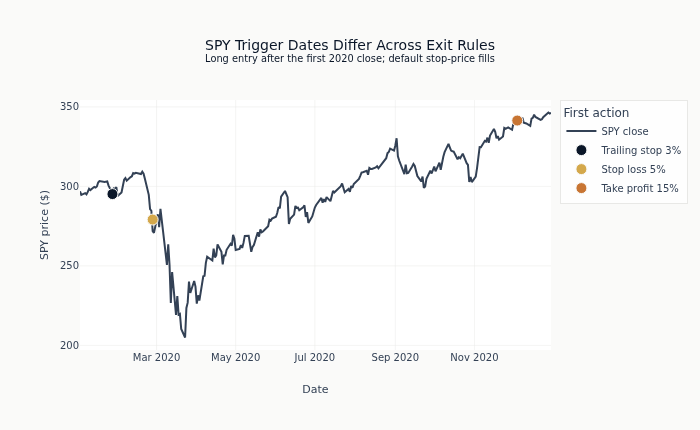

In [28]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=spy["timestamp"].to_list(),
        y=spy["close"].to_list(),
        name="SPY close",
        line=dict(color=COLORS["neutral"], width=2),
    )
)
for result, color in zip(
    trigger_results.iter_rows(named=True),
    ml4t_palette(trigger_results.height, categorical=True),
    strict=True,
):
    fig.add_trace(
        go.Scatter(
            x=[result["timestamp"]],
            y=[result["fill_price"]],
            mode="markers",
            name=result["rule"],
            marker=dict(color=color, size=11, line=dict(color=COLORS["bg_light"], width=1)),
            hovertemplate=(
                f"{result['rule']}<br>%{{x|%Y-%m-%d}}<br>Fill $%{{y:.2f}}<extra></extra>"
            ),
        )
    )
fig.update_layout(
    title=(
        "SPY Trigger Dates Differ Across Exit Rules"
        "<br><sup>Long entry after the first 2020 close; default stop-price fills</sup>"
    ),
    xaxis_title="Date",
    yaxis_title="SPY price ($)",
    height=430,
    legend_title_text="First action",
)
show_plotly_with_alt(
    fig,
    "A price path with markers showing where each rule in the chain would have triggered, so the order in which they fire is visible against the same series.",
)

### Rule Priority Across Position States

A close-only grid isolates composition semantics. When the 20-bar time exit
overlaps a price rule, `RuleChain` returns the earlier rule in its declared order.

In [29]:
return_grid = np.arange(-10, 16, 1)
bars_grid = np.arange(0, 31, 2)
exit_chain = RuleChain([StopLoss(pct=0.05), TakeProfit(pct=0.10), TimeExit(max_bars=20)])
exit_code = {"HOLD": 0, "stop_loss": 1, "take_profit": 2, "time_exit": 3}
exit_surface = np.zeros((len(bars_grid), len(return_grid)), dtype=int)

for row_idx, bars_held in enumerate(bars_grid):
    for col_idx, return_pct in enumerate(return_grid):
        state = create_position_state(
            entry_price=100.0,
            current_price=100.0 * (1 + return_pct / 100),
            bars_held=int(bars_held),
        )
        action = exit_chain.evaluate(state)
        reason_key = next((key for key in exit_code if action.reason.startswith(key)), "HOLD")
        exit_surface[row_idx, col_idx] = exit_code[reason_key]

The categorical map separates `HOLD`, entry stop, profit target, and time exit.
Its colors encode actions rather than performance.

In [30]:
exit_colors = [
    COLORS["silver_muted"],
    COLORS["negative"],
    COLORS["positive"],
    COLORS["amber"],
]
exit_scale = [
    [0.0, exit_colors[0]],
    [1 / 6, exit_colors[0]],
    [1 / 6, exit_colors[1]],
    [0.5, exit_colors[1]],
    [0.5, exit_colors[2]],
    [5 / 6, exit_colors[2]],
    [5 / 6, exit_colors[3]],
    [1.0, exit_colors[3]],
]

The colorbar names each action directly so the categorical codes never require
interpretation from the reader.

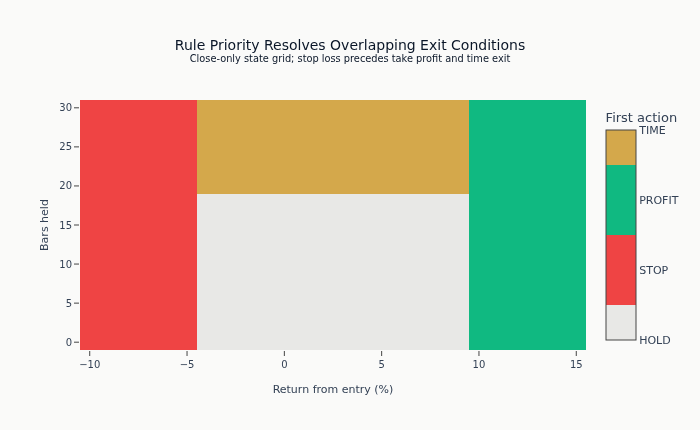

In [31]:
fig = go.Figure(
    go.Heatmap(
        x=return_grid,
        y=bars_grid,
        z=exit_surface,
        zmin=0,
        zmax=3,
        colorscale=exit_scale,
        colorbar=dict(
            title="First action",
            tickmode="array",
            tickvals=[0, 1, 2, 3],
            ticktext=["HOLD", "STOP", "PROFIT", "TIME"],
        ),
        hovertemplate="Return %{x}%<br>Bars %{y}<br>Action code %{z}<extra></extra>",
    )
)
fig.update_layout(
    title=(
        "Rule Priority Resolves Overlapping Exit Conditions"
        "<br><sup>Close-only state grid; stop loss precedes take profit and time exit</sup>"
    ),
    xaxis_title="Return from entry (%)",
    yaxis_title="Bars held",
    height=430,
)
show_plotly_with_alt(
    fig,
    "A grid of position states by rule, coloured by the action each rule returns, showing which rule claims each region of the state space under the chain's priority order.",
)

### Portfolio Escalation Surface

The portfolio map combines two independent checks without inventing realized
returns. Each cell constructs a `PortfolioState`, calls both limits, and reports
the more severe action if both are breached.

In [32]:
drawdown_grid = np.arange(0, 26, 2.5)
daily_loss_grid = np.arange(0, 4.1, 0.5)
portfolio_surface = np.zeros((len(drawdown_grid), len(daily_loss_grid)), dtype=int)

for row_idx, drawdown_pct in enumerate(drawdown_grid):
    for col_idx, daily_loss_pct in enumerate(daily_loss_grid):
        equity = 100000 * (1 - drawdown_pct / 100)
        state = create_portfolio_state(
            equity=equity,
            high_water_mark=100000,
            daily_pnl=-equity * daily_loss_pct / 100,
            num_positions=0,
            positions={},
        )
        actions = {
            result.action
            for result in (dd_limit.check(state), daily_limit.check(state))
            if result.breached
        }
        portfolio_surface[row_idx, col_idx] = (
            2 if "liquidate" in actions else 1 if "warn" in actions else 0
        )

The boundaries in the surface are the class contracts, not approximations of them: each limit
warns at one configured level and liquidates at another, and the daily-loss limit escalates
straight to liquidation with no warning band at all.

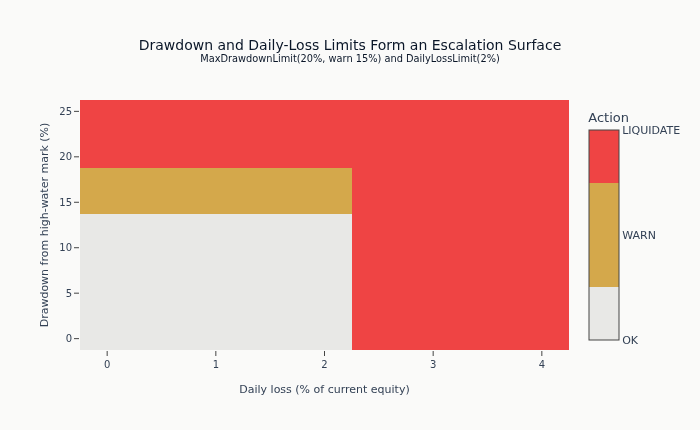

In [33]:
portfolio_colors = [COLORS["silver_muted"], COLORS["amber"], COLORS["negative"]]
portfolio_scale = [
    [0.0, portfolio_colors[0]],
    [0.25, portfolio_colors[0]],
    [0.25, portfolio_colors[1]],
    [0.75, portfolio_colors[1]],
    [0.75, portfolio_colors[2]],
    [1.0, portfolio_colors[2]],
]
fig = go.Figure(
    go.Heatmap(
        x=daily_loss_grid,
        y=drawdown_grid,
        z=portfolio_surface,
        zmin=0,
        zmax=2,
        colorscale=portfolio_scale,
        colorbar=dict(
            title="Action",
            tickmode="array",
            tickvals=[0, 1, 2],
            ticktext=["OK", "WARN", "LIQUIDATE"],
        ),
        hovertemplate="Daily loss %{x}%<br>Drawdown %{y}%<extra></extra>",
    )
)
fig.update_layout(
    title=(
        "Drawdown and Daily-Loss Limits Form an Escalation Surface"
        "<br><sup>MaxDrawdownLimit(20%, warn 15%) and DailyLossLimit(2%)</sup>"
    ),
    xaxis_title="Daily loss (% of current equity)",
    yaxis_title="Drawdown from high-water mark (%)",
    height=430,
)
show_plotly_with_alt(
    fig,
    "A surface of portfolio state by limit outcome in three bands - no action, warn, and liquidate - with the warning band visible only for the limits that define one.",
)

## 6. Demonstrated API Coverage

This inventory summarizes only the classes exercised above. The counts derive
from the names so they cannot drift from the displayed lists.

In [34]:
demonstrated_api = {
    "Position rules": (
        "StopLoss",
        "TakeProfit",
        "TimeExit",
        "TrailingStop",
        "TighteningTrailingStop",
        "ScaledExit",
    ),
    "Composition patterns": ("RuleChain", "AllOf", "AnyOf"),
    "Portfolio limits": (
        "MaxDrawdownLimit",
        "DailyLossLimit",
        "MaxPositionsLimit",
        "GrossExposureLimit",
        "NetExposureLimit",
    ),
}
library_coverage = pl.DataFrame(
    {
        "category": list(demonstrated_api),
        "count": [len(names) for names in demonstrated_api.values()],
        "examples": [", ".join(names) for names in demonstrated_api.values()],
    }
)
library_coverage

category,count,examples
str,i64,str
"""Position rules""",6,"""StopLoss, TakeProfit, TimeExit…"
"""Composition patterns""",3,"""RuleChain, AllOf, AnyOf"""
"""Portfolio limits""",5,"""MaxDrawdownLimit, DailyLossLim…"


**Section integration**:

- §19.4 references `StopLoss`, `TrailingStop`, and `TighteningTrailingStop`
  for drawdown and recovery management.
- §19.7 references `RuleChain` for adaptive controls.
- §19.8 references `MaxDrawdownLimit`, `DailyLossLimit` for kill switches.

## Key Takeaways

1. **Exit rules and portfolio limits are different controls and neither substitutes for the
   other.** A position rule sees one trade and decides whether to close it. A portfolio limit
   sees the book and decides whether to keep trading at all. A book can be full of individually
   healthy positions and still be over its drawdown limit, and a single position can need closing
   while the book is fine.

2. **Order inside a rule chain is policy, not implementation.** The first rule that fires wins,
   so a chain that evaluates the target before the stop will record a bar that breached both as a
   profitable exit. Decide the order deliberately and state it, as `02_exit_strategies` had to
   for the same reason.

3. **Know which rules carry state.** Most of these evaluate a position afresh each bar. The
   scaled exit does not: it remembers which targets have already fired, so reusing one instance
   across positions silently skips targets for the second position onward.

4. **Check what each rule is allowed to see on the current bar.** A trailing stop that reads the
   current bar's own high to set the water mark it then tests against is using information the
   order did not have. The default here takes the water mark from completed bars.

5. **Distinguish gross from net exposure and limit both.** Gross sums absolute positions and net
   sums signed ones. A market-neutral book sits near zero net while carrying substantial gross,
   and only one of the two limits would catch it levering up.

6. **A limit class enforces a threshold; it does not decide one.** The value comes from a risk
   mandate, and the surrounding procedure - who is told, who may override, what has to be true to
   resume - is not in the library and is what makes a kill switch usable.

### Known limitations

- Every example here is an evaluation of a constructed state, not a backtest. Nothing measures
  what applying these rules would have earned or cost, and the diagnostics show where rules fire
  rather than whether firing there was right.
- The position states are built by hand to sit either side of each threshold. That is the right
  way to demonstrate a contract and says nothing about how often real paths reach those states.
- No cost is charged on any exit. The rules differ mainly in how often they close positions,
  which is exactly what costs price.
- The portfolio limits are checked against a single snapshot of a book rather than a sequence, so
  nothing here exercises what happens after a limit breaches and trading halts.

API reference: `ml4t.backtest.risk`.

**Next**: [`11_systematic_risk_sweep`](11_systematic_risk_sweep.ipynb) applies these position
rules across grids of thresholds and reads the resulting surfaces.